In [1]:
!pip install basemap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 942.4/942.4 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.5/30.5 MB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 23.0 MB/s eta 0:00:00
  Attempting uninstall: pyproj
    Found existing installation: pyproj 3.7.0
    Uninstalling pyproj-3.7.0:
      Successfully uninstalled pyproj-3.7.0
  Attempting uninstall: packaging
    Found existing installation: packaging 24.2
    Uninstalling packaging-24.2:
      Successfully uninstalled packaging-24.2
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0


In [1]:
%matplotlib inline
%pylab inline
from mpl_toolkits.basemap import Basemap
import pandas as pd
import warnings
warnings.filterwarnings("ignore") # disable warnings
pylab.rcParams['figure.figsize']=(15,15) # graph size

Populating the interactive namespace from numpy and matplotlib


In [3]:
rcParams.update({'font.size': 14})

**Connection to the GCP:**


First, we have to connect to the Google Cloud Platform. Enter the login "bigdataocean2020@gmail.com" and password "bdoimt2023". Do it only once. We will maybe need an authentication: contact me at pierre.tandeo@imt-atlantique.fr.


In [2]:
import os
os.environ['USE_AUTH_EPHEM'] = '0'

from google.colab import auth
auth.authenticate_user()

In [5]:
%%bigquery output --project alert-ground-261008
SELECT time, AVG(sst) AS mean_sst, AVG(ssh) AS mean_ssh
FROM bdo2020.bdo2020.1998_2015

GROUP BY time
ORDER BY time

Query is running:   0%|          |

Downloading:   0%|          |

In [ ]:
output.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6574 entries, 0 to 6573
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   time      6574 non-null   float64
 1   mean_sst  6574 non-null   float64
 2   mean_ssh  6574 non-null   float64
dtypes: float64(3)
memory usage: 154.2 KB


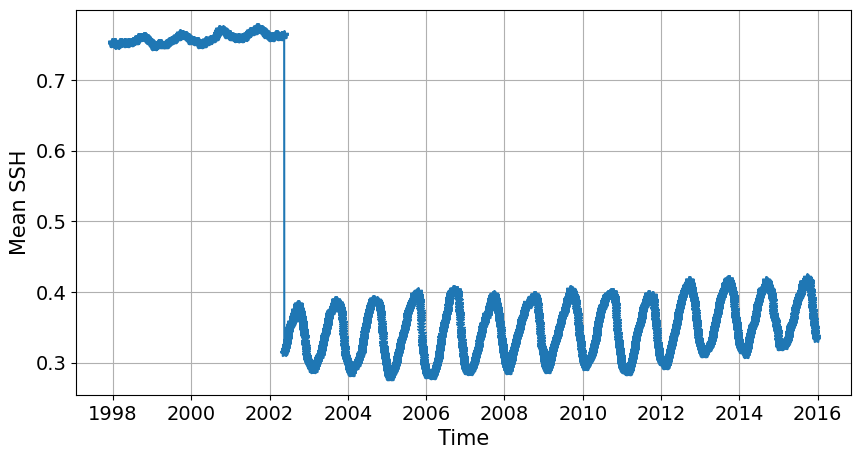

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def plot_ts(time,ts,line_type,var_name):
    # plot
    plt.figure(figsize=(10,5))
    plt.plot_date(time-719177.25,ts,line_type)
    plt.xlabel('Time',fontsize=15)
    plt.ylabel(var_name,fontsize=15)

t = np.array(output['time'])
m_ssh = np.array(output['mean_ssh'])
plot_ts(t,m_ssh, '-*', 'Mean SSH')
plt.grid()

In [ ]:
df_1 = output[output['mean_ssh'] > 0.5]
df_2 = output[output['mean_ssh'] <= 0.5]

15th may 2001

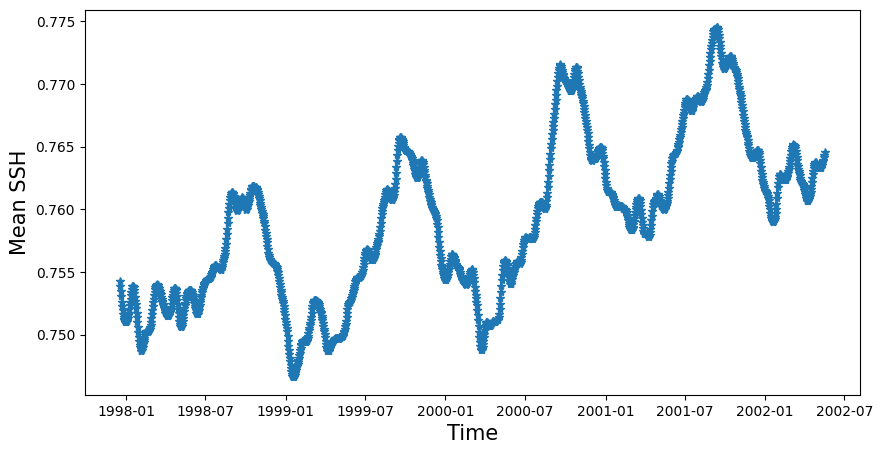

In [ ]:
plot_ts(df_1['time'],df_1['mean_ssh'], '-*', 'Mean SSH')

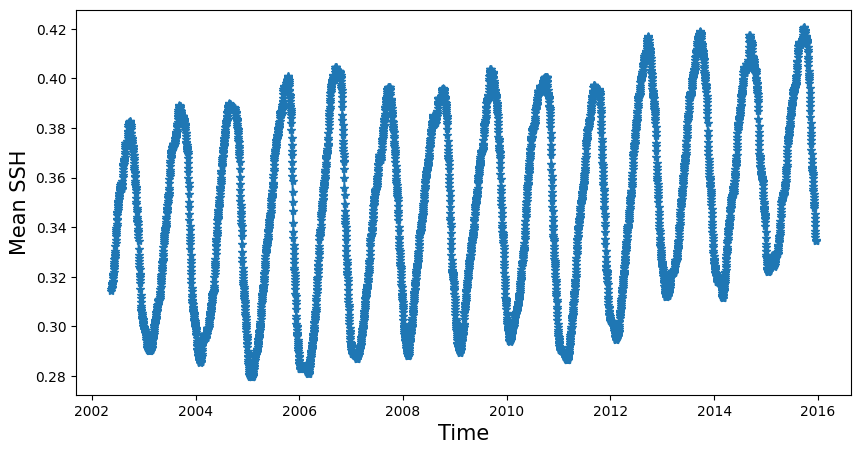

In [ ]:
plot_ts(df_2['time'],df_2['mean_ssh'], '-*', 'Mean SSH')

Sur la region -40 < lat < 40 :

In [7]:
%%bigquery output_40 --project alert-ground-261008
SELECT time, AVG(sst) AS mean_sst, AVG(ssh) AS mean_ssh
FROM bdo2020.bdo2020.1998_2015
WHERE lat > -40 AND lat < 40
GROUP BY time
ORDER BY time

Query is running:   0%|          |

Downloading:   0%|          |

In [8]:
output_40['mean_ssh'] = output_40['mean_ssh'] - output_40['mean_ssh'].mean()

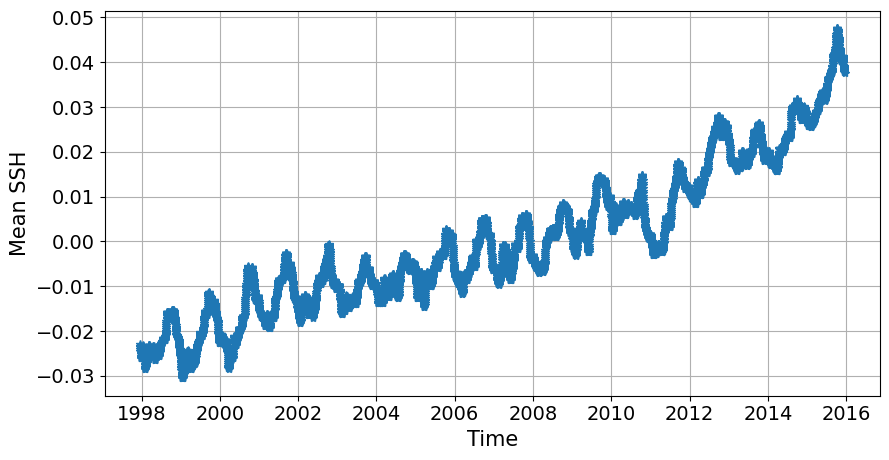

In [9]:
t = np.array(output['time'])
m_ssh = np.array(output_40['mean_ssh'])
plot_ts(t,m_ssh, '-*', 'Mean SSH')
plt.grid()

In [10]:
import sklearn
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score

In [11]:
X = pd.DataFrame(output_40['time'])
scaler = MinMaxScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=['time_scaled'])
X_2 = pd.DataFrame(X['time_scaled']*X['time_scaled'])
X_exp = pd.DataFrame(np.exp(X['time_scaled']))


In [12]:
output_40['time_scaled'] = X['time_scaled']

In [13]:
linear = LinearRegression()
linear.fit(X.iloc[:int(0.7 * len(X))], output_40['mean_ssh'].iloc[:int(0.7 * len(X))])
y = linear.predict(X)

squarred = LinearRegression()
squarred.fit(X_2.iloc[:int(0.7 * len(X))], output_40['mean_ssh'].iloc[:int(0.7 * len(X))])
y_2 = squarred.predict(X_2)

exp = LinearRegression()
exp.fit(X_exp.iloc[:int(0.7 * len(X))], output_40['mean_ssh'].iloc[:int(0.7 * len(X))])
y_exp = exp.predict(X_exp)


In [14]:
print('R2 with linear model : ', r2_score(output_40['mean_ssh'], y))
print('R2 with squarred model : ', r2_score(output_40['mean_ssh'], y_2))
print('R2 with exponential model : ', r2_score(output_40['mean_ssh'], y_exp))

R2 with linear model :  0.8412624224665154
R2 with squarred model :  0.8704840089281912
R2 with exponential model :  0.9029414573557598


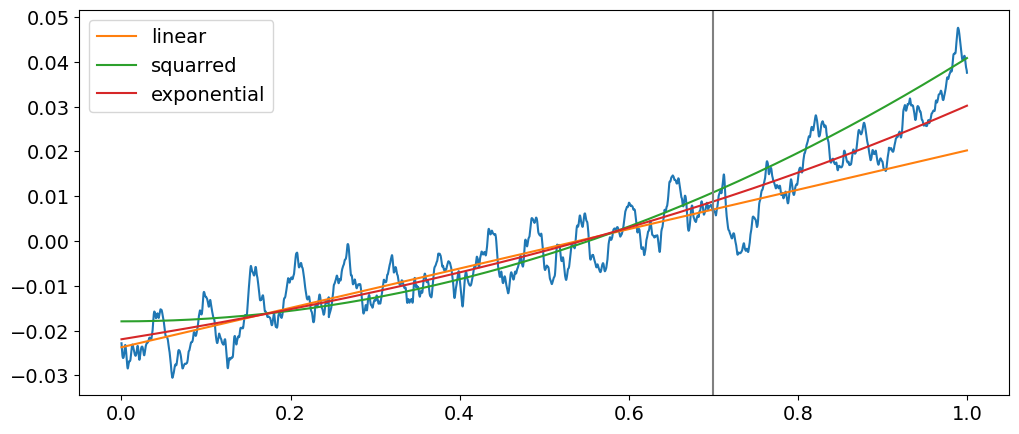

In [15]:
plt.figure(figsize=(12,5))
plt.plot(output_40['time_scaled'],output_40['mean_ssh'])
plt.plot(X['time_scaled'], y, label='linear')
plt.plot(X['time_scaled'], y_2, label='squarred')
plt.plot(X['time_scaled'], y_exp, label='exponential')
plt.axvline(x=0.7,color='gray')
plt.legend()

In [16]:
X = pd.DataFrame(output_40['time'], columns=['time'])
X['cos'] = np.cos(2*np.pi*X['time']/365.25)
X['sin'] = np.sin(2*np.pi*X['time']/365.25)
scaler = MinMaxScaler()
X['time_scaled'] = scaler.fit_transform(pd.DataFrame(X['time']))
X['exp'] = np.exp(X['time_scaled'])
X = X.drop(columns='time')

In [17]:
exp = LinearRegression()
exp.fit(X.iloc[:int(0.7 * len(X))], output_40['mean_ssh'].iloc[:int(0.7 * len(X))])
y = exp.predict(X)

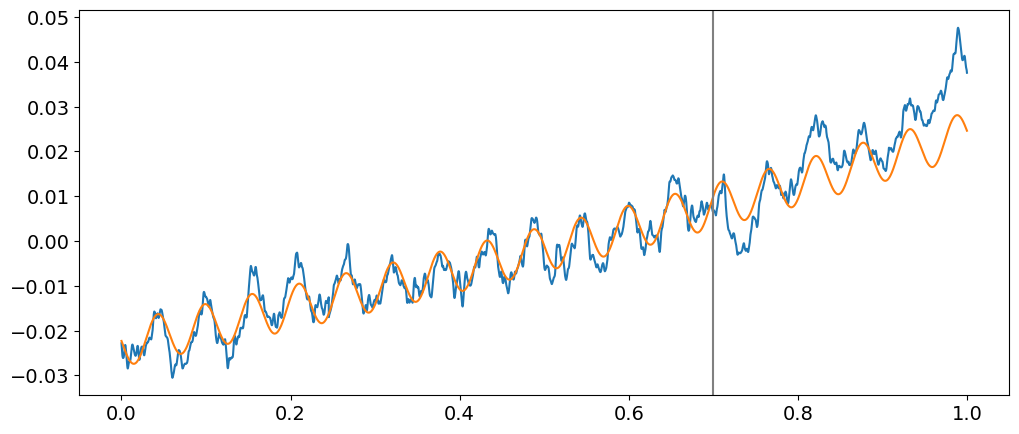

In [18]:
plt.figure(figsize=(12,5))
plt.plot(output_40['time_scaled'],output_40['mean_ssh'])
plt.plot(X['time_scaled'], y)
plt.axvline(x=0.7,color='gray')

In [ ]:
print('R2 with exponential model : ', r2_score(output_40['mean_ssh'], y))

R2 with exponential model :  0.9231623543280618


In [ ]:
df_2['mean_ssh'] = df_2['mean_ssh'] - df_2['mean_ssh'].mean()

In [ ]:
X = pd.DataFrame(output['time'], columns=['time'])
X['cos'] = np.cos(2*np.pi*X['time']/365.25)
X['sin'] = np.sin(2*np.pi*X['time']/365.25)
scaler = MinMaxScaler()
X['time_scaled'] = scaler.fit_transform(pd.DataFrame(X['time']))
X['exp'] = np.exp(X['time_scaled'])
X = X.drop(columns='time')

In [ ]:
exp = LinearRegression()
exp.fit(X.iloc[:int(0.7 * len(X))], df_2['mean_ssh'].iloc[:int(0.7 * len(X))])
y_whole = exp.predict(X)

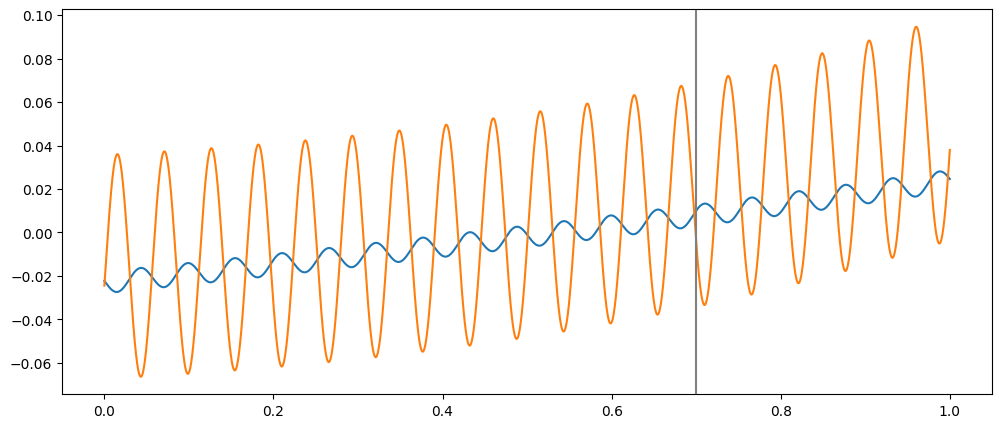

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(X['time_scaled'], y)
plt.plot(X['time_scaled'], y_whole)
plt.axvline(x=0.7,color='gray')

Modèle final 🇰

In [19]:
X = pd.DataFrame(output_40['time'], columns=['time'])
X['cos'] = np.cos(2*np.pi*X['time']/365.25)
X['sin'] = np.sin(2*np.pi*X['time']/365.25)
X['exp'] = np.exp(X['time']/X['time'].iloc[0])

In [20]:
exp_cs = LinearRegression()
exp_cs.fit(X, output_40['mean_ssh'])
y = exp_cs.predict(X)

In [21]:
X_test = pd.DataFrame(output_40['time'], columns=['time'])
days_to_add = (90 * 365) + 90//4
last_value = int(X_test['time'].iloc[-1])
new_values = range(last_value + 1, last_value + 1 + days_to_add)
days = pd.DataFrame({'time': new_values})
X_test = pd.concat([X_test, days], ignore_index=True)

X_test['cos'] = np.cos(2*np.pi*X_test['time']/365.25)
X_test['sin'] = np.sin(2*np.pi*X_test['time']/365.25)
X_test['exp'] = np.exp(X_test['time']/X_test['time'].iloc[0])

In [22]:
y_90 = exp_cs.predict(X_test)

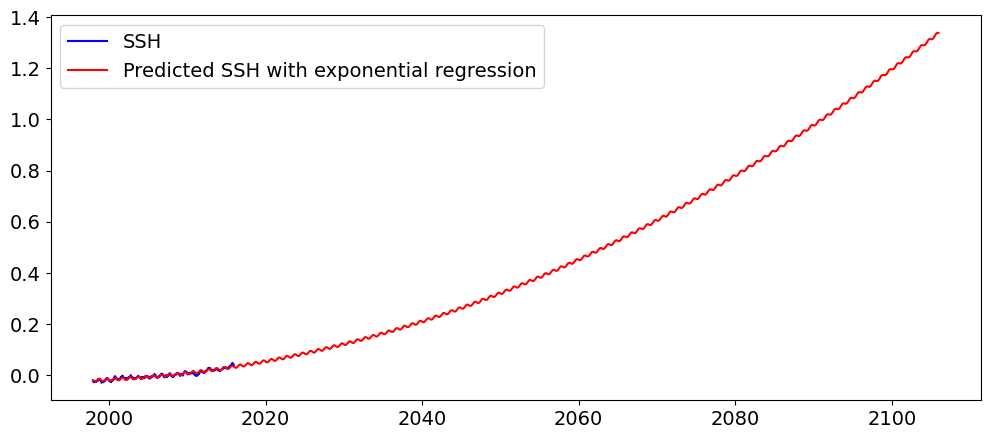

In [23]:
plt.figure(figsize=(12,5))
plt.plot_date(output_40['time']-719177.25,output_40['mean_ssh'],'-',label='SSH', color='blue')
#plt.plot(output_40['time'],output_40['mean_ssh'])
#plt.plot(X_test['time'], y_90)
plot_date(X_test['time']-719177.25,y_90,'-',label='Predicted SSH with exponential regression', color='red')
plt.legend()

Sigma : 0.0028570033697513917
----------------------------


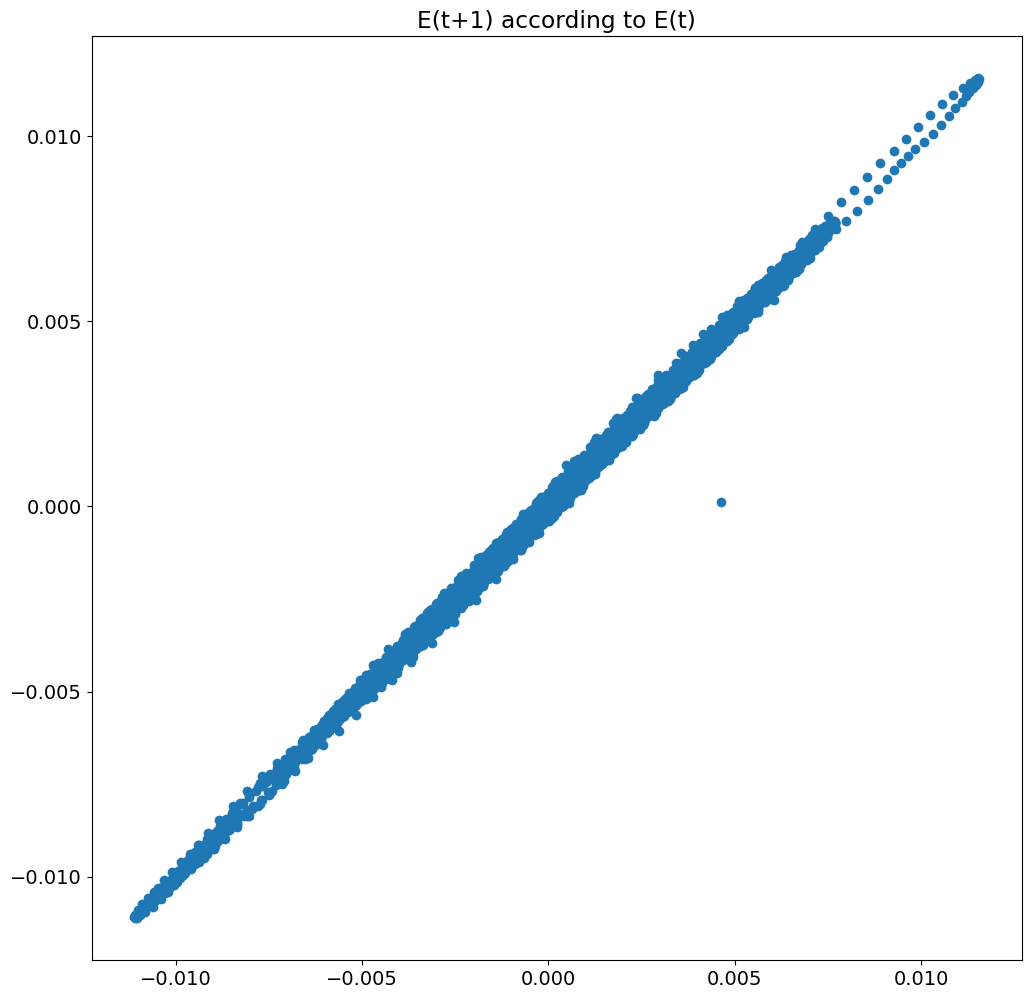

----------------------------
The slope is : 0.9989403740225967


In [41]:
from scipy.stats import linregress

res = output_40['mean_ssh'] - y_90[:6574]
sigma = abs(res).mean()

print(f"Sigma : {sigma}")
print('----------------------------')

#Error in t+1 according to Error in t

resplus1 = list(res)
resplus1.pop(0)
resplus1.append(list(res)[-1])
plt.figure(figsize=(12,12))

plt.scatter(res,resplus1)
slope, intercept, r_value, p_value, std_err = linregress(res,resplus1)
plt.title("E(t+1) according to E(t)")
plt.show()
print('----------------------------')
print(f"The slope is : {slope}")
#Slope almost 1 so linear model

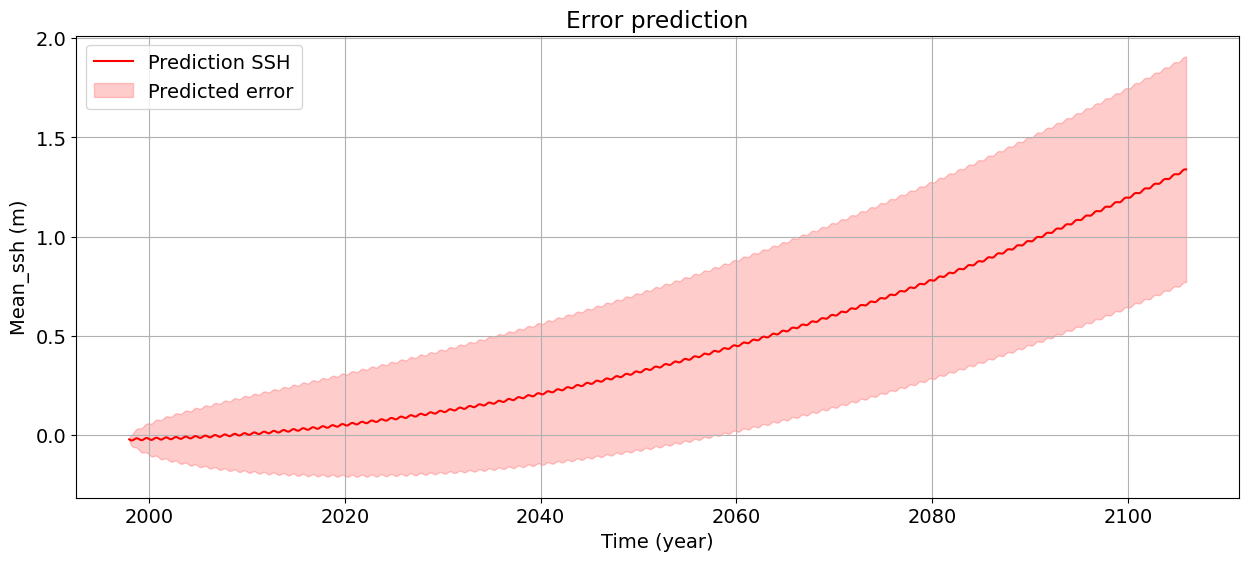

In [27]:
phi = slope

tphi=[]
t0 = X_test['time'][0]
for i in X_test['time']:
  tphi.append(i-t0)


def g(t):
  return((t**0.5)*sigma)

e_t1 = list(map(g, tphi))

y_pred_upper = y_90 + e_t1
y_pred_lower = y_90 - e_t1


plt.figure(figsize=(15, 6))
plt.plot_date(X_test['time']-719177.25, y_90,'-', label="Prediction SSH", color="red")


plt.fill_between(X_test['time']-719177.25, y_pred_lower, y_pred_upper, color="red", alpha=0.2, label="Predicted error")

#plt.plot_date(X_test['time']-719177.25, e_t1, label="Predicted error $f(t)$", color="red")

# Décorations
plt.title("Error prediction")
plt.xlabel("Time (year)")
plt.ylabel("Mean_ssh (m)")
plt.legend(loc="upper left")
plt.grid(True)
plt.show()


-----------------

Modele sinusoidale avec les residuals

In [28]:
%%bigquery output40 --project alert-ground-261008
SELECT time, AVG(sst) AS mean_sst, AVG(ssh) AS mean_ssh
FROM bdo2020.bdo2020.1998_2015
WHERE lat>-40 AND lat<40
GROUP BY time
ORDER BY time

Query is running:   0%|          |

Downloading:   0%|          |

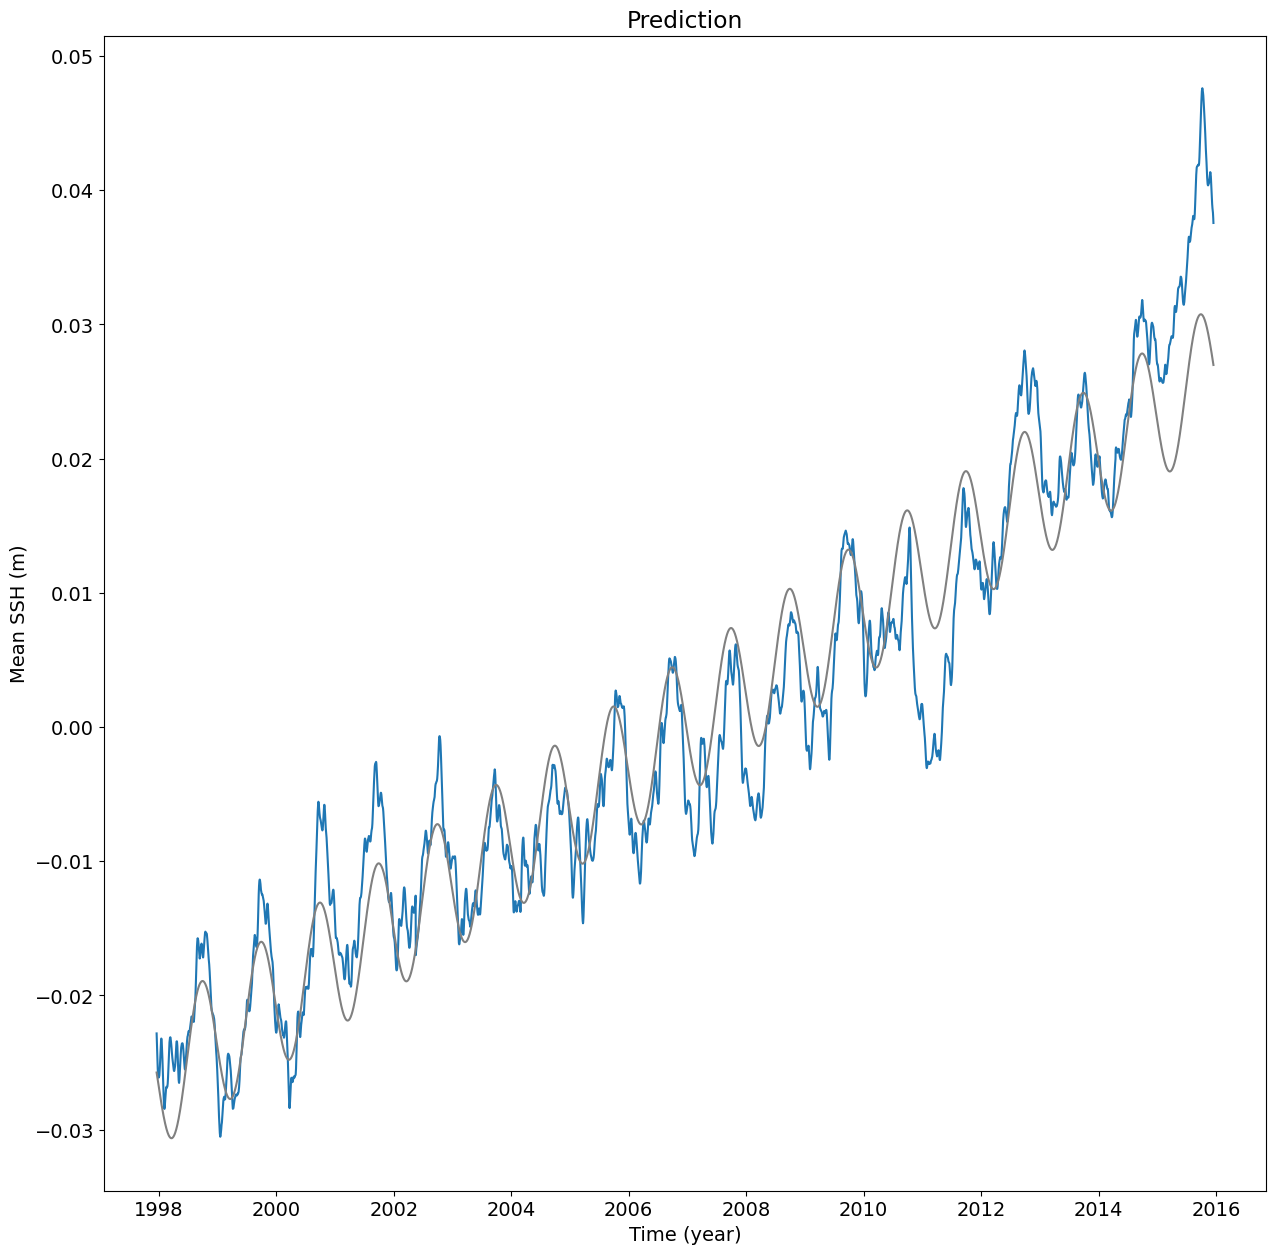

In [29]:
from sklearn.linear_model import LinearRegression


t=output40['time']
mean_ssh = output40['mean_ssh'] - output40['mean_ssh'].mean()

X=vstack((t,sin(2*pi*(1/365.25)*t),cos(2*pi*(1/365.25)*t))).T
t_pred=linspace(729390,765963,765963-729389)
X_pred=vstack((t_pred,sin(2*pi*(1/365.25)*t_pred),cos(2*pi*(1/365.25)*t_pred))).T
y=mean_ssh
reg=LinearRegression().fit(X,y)
y_pred=reg.predict(X)
y_pred2 = reg.predict(X_pred)

plt.plot_date(t-719177.25, y,'-')
plt.plot_date(t-719177.25, y_pred,'-', color='grey')
#plt.plot(t_pred, y_pred2, color='grey')
plt.title("Prediction")
plt.ylabel("Mean SSH (m)")
plt.xlabel("Time (year)")
plt.show()

Sigma : 0.003371281076208369
----------------------------


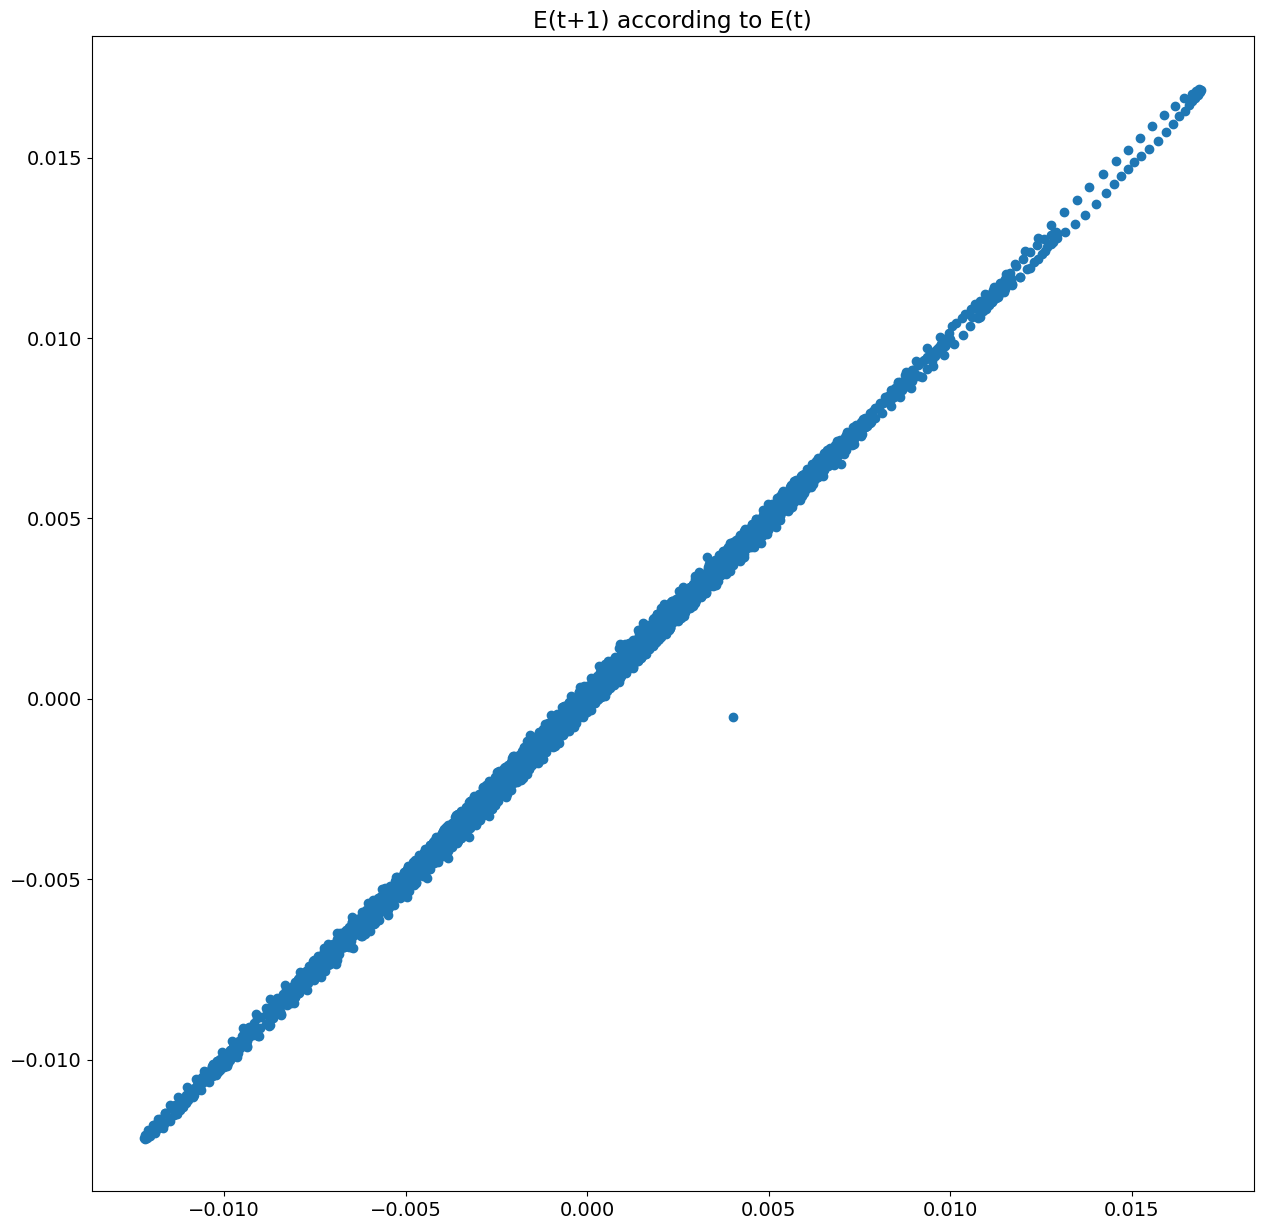

----------------------------
The slope is : 0.9996368419530061


In [30]:
from scipy.stats import linregress

res = mean_ssh - y_pred
sigma = abs(res).mean()


print(f"Sigma : {sigma}")
print('----------------------------')

#Error in t+1 according to Error in t

resplus1 = list(res)
resplus1.pop(0)
resplus1.append(list(res)[-1])

plt.scatter(res,resplus1)
slope, intercept, r_value, p_value, std_err = linregress(res,resplus1)
plt.title("E(t+1) according to E(t)")
plt.show()
print('----------------------------')
print(f"The slope is : {slope}")
#Slope almost 1 so linear model

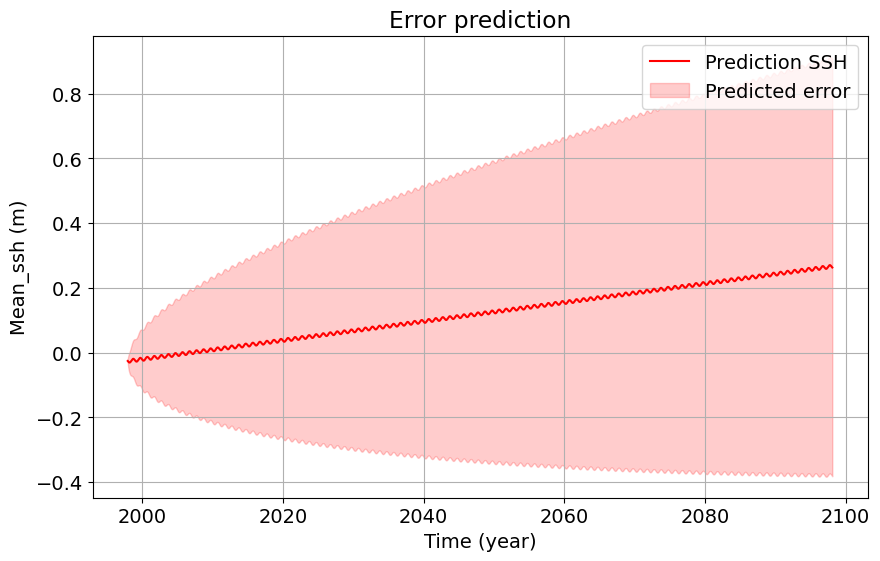

In [31]:
phi = slope

tphi=[]
t0 = t_pred[0]
for i in t_pred:
  tphi.append(i-t0)


def g(t):
  return((t**0.5)*sigma)

e_t1 = list(map(g, tphi))

y_pred_upper = y_pred2 + e_t1
y_pred_lower = y_pred2 - e_t1


plt.figure(figsize=(10, 6))
plt.plot_date(t_pred-719177.25, y_pred2,'-', label="Prediction SSH", color="red")


plt.fill_between(t_pred-719177.25, y_pred_lower, y_pred_upper, color="red", alpha=0.2, label="Predicted error")

#plt.plot_date(t_pred-719177.25, e_t1, label="Predicted error $f(t)$", color="red")

# Décorations
plt.title("Error prediction")
plt.xlabel("Time (year)")
plt.ylabel("Mean_ssh (m)")
plt.legend()
plt.grid(True)
plt.show()


Modèle linéaire & quadratique & sinusoïdal, avec résidus



In [32]:
t = output_40['time']
m_ssh = output_40['mean_ssh']-output_40['mean_ssh'].mean()

R-squared score for bi-seasonal : 0.9557950234552335
R-squared score for seasonal : 0.9517880015890648
R-squared score for seasonal_log : 0.9311055929648241
R-squared score for seasonal_sqrt : 0.9387208537247185


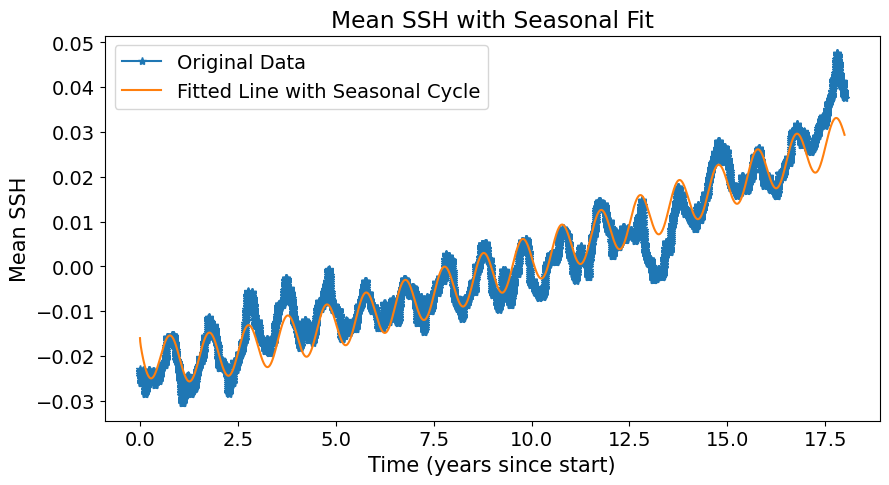

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Assuming 't' and 'm_ssh' are your time and mean SSH data
#  Make sure 't' and 'm_ssh' are defined from your previous code

# Convert time to years since the start of the dataset
t_years = (t - t[0]) / 365.25

# Create time features for the seasonal cycle
t_years = t_years.values.reshape(-1,1)

Models = ["bi-seasonal","seasonal","seasonal_log","seasonal_sqrt"]
MODELS = []

for model_str in Models:
  if model_str=="bi-seasonal":
    time_features = np.column_stack([
        t_years, # linear trend
        t_years**2,
        np.sin(2 * np.pi * t_years),  # annual cycle
        np.cos(2 * np.pi * t_years),
        np.sin(4 * np.pi * t_years), #semi annual cycle
        np.cos(4 * np.pi * t_years)])
        #])
  elif model_str=="seasonal":
    time_features = np.column_stack([
        t_years, # linear trend
        t_years**2,
        np.sin(2 * np.pi * t_years),  # annual cycle
        np.cos(2 * np.pi * t_years)])
  elif model_str=="seasonal_log":
    time_features = np.column_stack([
        t_years, # linear trend
        np.log(t_years+1e-15),
        np.sin(2 * np.pi * t_years),  # annual cycle
        np.cos(2 * np.pi * t_years)])
  elif model_str=="seasonal_sqrt":
    time_features = np.column_stack([
        t_years, # linear trend
        np.sqrt(t_years),
        np.sin(2 * np.pi * t_years),  # annual cycle
        np.cos(2 * np.pi * t_years)])

  # Create and fit the linear regression model with time features
  model = LinearRegression()
  model.fit(time_features, m_ssh)

  MODELS.append(model)
  # Get the predicted values
  m_ssh_pred = model.predict(time_features)

  r2_score = model.score(time_features, m_ssh)
  print("R-squared score for {} : {}".format(model_str,r2_score))

# Plot the original data and the fitted line
plt.figure(figsize=(10, 5))
plt.plot(t_years, m_ssh, '-*', label='Original Data')
plt.plot(t_years, m_ssh_pred, '-', label='Fitted Line with Seasonal Cycle')
plt.xlabel('Time (years since start)', fontsize=15)
plt.ylabel('Mean SSH', fontsize=15)
plt.title('Mean SSH with Seasonal Fit')
plt.legend()
plt.show()


seas_model = MODELS[1]
log_model = MODELS[2]
sqrt_model = MODELS[3]

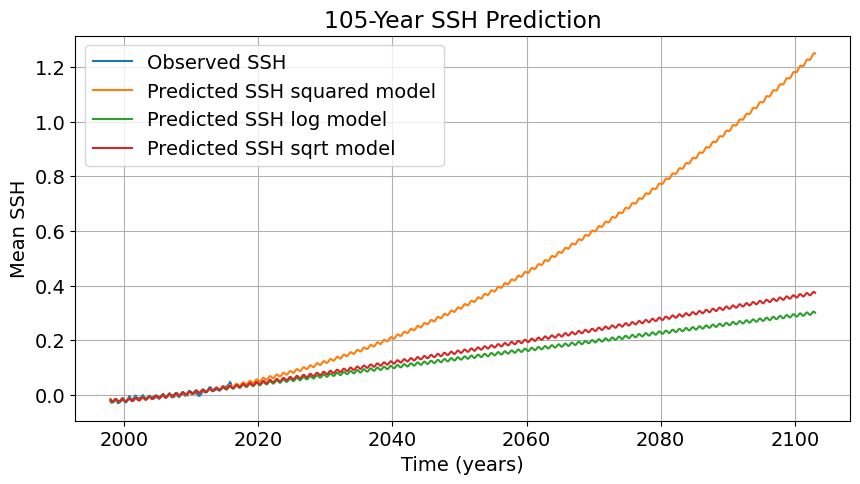

In [35]:
# Create future time points for prediction (100 years)
t_end = 105
#future_years = np.arange(t_years[-1,0] + 1/365.25, t_years[-1,0] + 300, 1/365.25).reshape(-1,1)
future_years = np.arange(1/365.25, t_end, 1/365.25).reshape(-1,1)

# Create time features for the future predictions
future_time_features_squared = np.column_stack([
    future_years,
    future_years**2,
    np.sin(2 * np.pi * future_years),
    np.cos(2 * np.pi * future_years)
])

future_time_features_log = np.column_stack([
    future_years,
    np.log(future_years+1e-15),
    np.sin(2 * np.pi * future_years),
    np.cos(2 * np.pi * future_years)
])

future_time_features_sqrt = np.column_stack([
    future_years,
    np.sqrt(future_years),
    np.sin(2 * np.pi * future_years),
    np.cos(2 * np.pi * future_years)
])

# Predict using the seasonal model
future_ssh_pred_squared = seas_model.predict(future_time_features_squared)
future_ssh_pred_log = log_model.predict(future_time_features_log)
future_ssh_pred_sqrt = sqrt_model.predict(future_time_features_sqrt)

# Plot the predictions
plt.figure(figsize=(10, 5))
plt.plot(1998+t_years, m_ssh, label='Observed SSH')
plt.plot(1998+future_years, future_ssh_pred_squared, label='Predicted SSH squared model')
plt.plot(1998+future_years, future_ssh_pred_log, label='Predicted SSH log model')
plt.plot(1998+future_years, future_ssh_pred_sqrt, label='Predicted SSH sqrt model')
plt.xlabel('Time (years)')
plt.ylabel('Mean SSH')
plt.title('{}-Year SSH Prediction'.format(t_end))
plt.legend()
plt.grid()
plt.show()

In [36]:
from scipy.stats import linregress

def res(y):
  r = m_ssh - y[:6574]
  sig = abs(r).mean()
  return sig


#Error in t+1 according to Error in t
def er(r):
  resplus1 = list(r)
  resplus1.pop(0)
  resplus1.append(list(r)[-1])
  slope, intercept, r_value, p_value, std_err = linregress(r,resplus1)
  return slope # Slope always almost 1 so OK

sigma_squared = res(future_ssh_pred_squared)
sigma_log = res(future_ssh_pred_log)
sigma_sqrt = res(future_ssh_pred_sqrt)

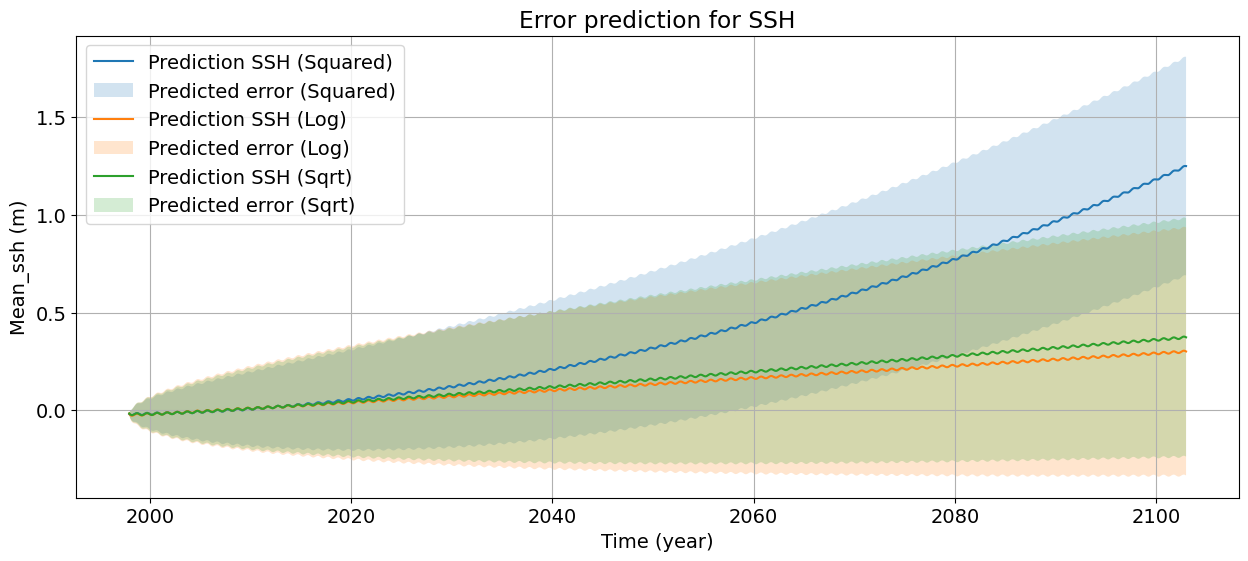

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# Exemple de données t_pred
t_pred = np.linspace(729390, 767740, 767740 - 729389)

# Fonction g(t, sigma)
def g(t, sigma):
    return (t**0.5) * sigma

# Fonction pour afficher les courbes
def grap(y1, sigma1, y2, sigma2, y3, sigma3):

    tlist = []
    t0 = t_pred[0]
    for i in t_pred:
        tlist.append(i - t0)


    e_t1 = list(map(lambda l: g(l, sigma1), tlist))
    e_t2 = list(map(lambda l: g(l, sigma2), tlist))
    e_t3 = list(map(lambda l: g(l, sigma3), tlist))

    y_pred_upper_1 = y1 + e_t1
    y_pred_lower_1 = y1 - e_t1

    y_pred_upper_2 = y2 + e_t2
    y_pred_lower_2 = y2 - e_t2

    y_pred_upper_3 = y3 + e_t3
    y_pred_lower_3 = y3 - e_t3


    plt.figure(figsize=(15, 6))

    plt.plot_date(t_pred - 719177.25, y1, '-', label="Prediction SSH (Squared)")
    plt.fill_between(t_pred - 719177.25, y_pred_lower_1, y_pred_upper_1, alpha=0.2, label="Predicted error (Squared)")

    plt.plot_date(t_pred - 719177.25, y2, '-', label="Prediction SSH (Log)")
    plt.fill_between(t_pred - 719177.25, y_pred_lower_2, y_pred_upper_2, alpha=0.2, label="Predicted error (Log)")

    plt.plot_date(t_pred - 719177.25, y3, '-', label="Prediction SSH (Sqrt)")
    plt.fill_between(t_pred - 719177.25, y_pred_lower_3, y_pred_upper_3, alpha=0.2, label="Predicted error (Sqrt)")

    plt.title("Error prediction for SSH")
    plt.xlabel("Time (year)")
    plt.ylabel("Mean_ssh (m)")
    plt.legend()
    plt.grid(True)
    plt.show()

grap(future_ssh_pred_squared, sigma_squared,
     future_ssh_pred_log, sigma_log,
     future_ssh_pred_sqrt, sigma_sqrt)


-----------------------------------------------------------------------------------------------------------------

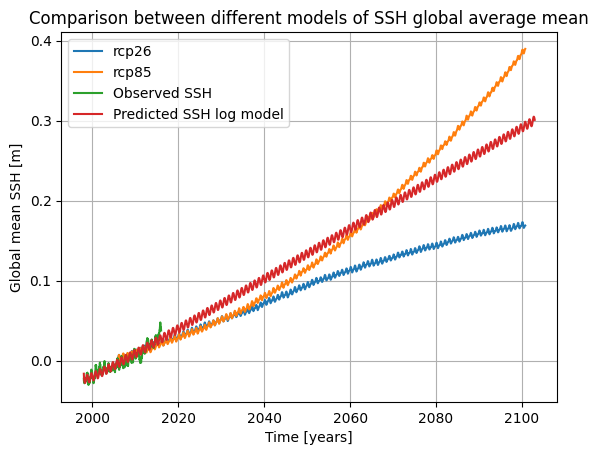

In [ ]:

import numpy as np
import netCDF4
import matplotlib.pyplot as plt

net_CDF_file_ssp126 = netCDF4.Dataset(r'zostoga_Omon_IPSL-CM6A-LR_ssp126_r4i1p1f1_gn_201501-210012.nc','r')
net_CDF_file_ssp585 = netCDF4.Dataset(r'zostoga_Omon_IPSL-CM6A-LR_ssp585_r2i1p1f1_gn_201501-210012.nc','r')
net_CDF_file_rcp26 = netCDF4.Dataset(r'zostoga_Omon_CanESM5_rcp26-cmip5_r2i1p1f1_gn_200601-210012.nc','r')
net_CDF_file_rcp85 =  netCDF4.Dataset(r'zostoga_Omon_CanESM5_rcp85-cmip5_r4i1p1f1_gn_200601-210012.nc','r')


FILES = [net_CDF_file_rcp26,net_CDF_file_rcp85]
model_name = ["rcp26","rcp85"]

plt.figure()
plt.xlabel("Time [years]")
plt.ylabel("Global mean SSH [m]")
plt.title("Comparison between different models of SSH global average mean")


for i, net_CDF_file in enumerate(FILES):
    time = net_CDF_file.variables["time"]
    zostoga = net_CDF_file.variables["zostoga"]
    min=np.min(zostoga[:] - np.mean(zostoga[:]))


    #plt.title("Ouptut of the ssp126 experiment at \n Lon: {} ° \n Lat: {} °".format(round(lon[0][0],2),round(lat[0][0])))

    plt.plot(1850 + time[:]/365.25, zostoga[:] - np.mean(zostoga[:])-min ,label=model_name[i])


plt.plot(1998+t_years, m_ssh, label='Observed SSH')
#plt.plot(1998+future_years, future_ssh_pred_squared, label='Predicted SSH squared model')
plt.plot(1998+future_years, future_ssh_pred_log, label='Predicted SSH log model')
#plt.plot(1998+future_years, future_ssh_pred_sqrt, label='Predicted SSH sqrt model')
plt.legend()
plt.grid()
plt.show()

In [ ]:
from scipy.stats import linregress

def res(y):
  r = mean_ssh - y_90[:6574]
  sig = abs(r).mean()

print(f"Sigma : {sigma}")
print('----------------------------')

#Error in t+1 according to Error in t

resplus1 = list(res)
resplus1.pop(0)
resplus1.append(list(res)[-1])

plt.scatter(res,resplus1)
slope, intercept, r_value, p_value, std_err = linregress(res,resplus1)
plt.title("E(t+1) according to E(t)")
plt.show()
print('----------------------------')
print(f"The slope is : {slope}")
#Slope almost 1 so linear model

Sigma : 0.003371281076208369
----------------------------


TypeError: 'function' object is not iterable

In [ ]:
t_years[1] - t_years[0]
print(t_years[0])
print(np.arange(t_years[0],100,t_years[1] - t_years[0]))

# Map pixels x pixels

In [ ]:
# function to plot images
def plot_im(lon,lat,im,size_points,var_name):

    # transform to arrays (just in case)
    lon=np.array(lon)
    lat=np.array(lat)
    im=np.array(im)

    if np.max(lon)-np.min(lon)<100:
      # Mercator projection (for small zone)
      m=Basemap(projection='merc',llcrnrlat=np.nanmin(lat),urcrnrlat=np.nanmax(lat),\
                llcrnrlon=np.nanmin(lon),urcrnrlon=np.nanmax(lon),lat_0=(np.nanmax(lat)+np.nanmin(lat))*0.5,\
                lon_0=(np.nanmax(lon)+np.nanmin(lon))*0.5,resolution='l')
    else:
      # Orthogonal projection (for large zone)
      m=Basemap(projection='robin',lat_0=0,lon_0=0,resolution='l')
    # you can use other projections (see https://matplotlib.org/basemap/users/mapsetup.html)

    # transform (lon,lat) to (x,y)
    x,y=m(lon,lat)

    # plot
    #im=ma.masked_where(isnan(im),im)
    res=m.scatter(x,y,size_points,im,'o',alpha=1,cmap='bwr',lw=0,vmin=-1.5, vmax=1.5)
    m.drawcoastlines()
    m.fillcontinents()
    parallels = np.linspace(np.nanmin(lat),np.nanmax(lat),15)
    meridians = np.linspace(np.nanmin(lon),np.nanmax(lon),15)
    #m.drawparallels(parallels,labels=[1,0,0,1],fontsize=10)
    #m.drawmeridians(meridians,labels=[1,0,0,1],fontsize=10)
    cb=m.colorbar(res,location="right")
    cb.set_label(var_name,fontsize=15)

In [ ]:
!pip install Basemap


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 942.4/942.4 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.5/30.5 MB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 84.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 48.6 MB/s eta 0:00:00
  Attempting uninstall: pyproj
    Found existing installation: pyproj 3.7.0
    Uninstalling pyproj-3.7.0:
      Successfully uninstalled pyproj-3.7.0
  Attempting uninstall: packaging
    Found existing installation: packaging 24.2
    Uninstalling packaging-24.2:
      Successfully uninstalled packaging-24.2
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.10.0
    Uninstalling matplotlib-3.10.0:
      Successfully uninstalled matplotlib-3.10.0


In [ ]:
%%bigquery ssh_slope --project alert-ground-261008
WITH first_year_avg AS (
  SELECT lat, lon, AVG(ssh) AS mean_ssh_first
  FROM bdo2020.bdo2020.1998_2015
  WHERE time > 731002.0 AND time < 731367.0
  GROUP BY lat, lon
),
last_year_avg AS (
  SELECT lat, lon, AVG(ssh) AS mean_ssh_last
  FROM bdo2020.bdo2020.1998_2015
  WHERE time > 735598.0 AND time < 735963.0
  GROUP BY lat, lon
)
SELECT f.lat, f.lon, f.mean_ssh_first, l.mean_ssh_last, (l.mean_ssh_last - f.mean_ssh_first) / ((735963.0-731002.0)/365) AS slope
FROM first_year_avg f
LEFT JOIN last_year_avg l
ON f.lat = l.lat AND f.lon = l.lon

Query is running:   0%|          |

Downloading:   0%|          |

Text(0.5, 1.0, 'How fast the sea surface rose over the years 2002-2015')

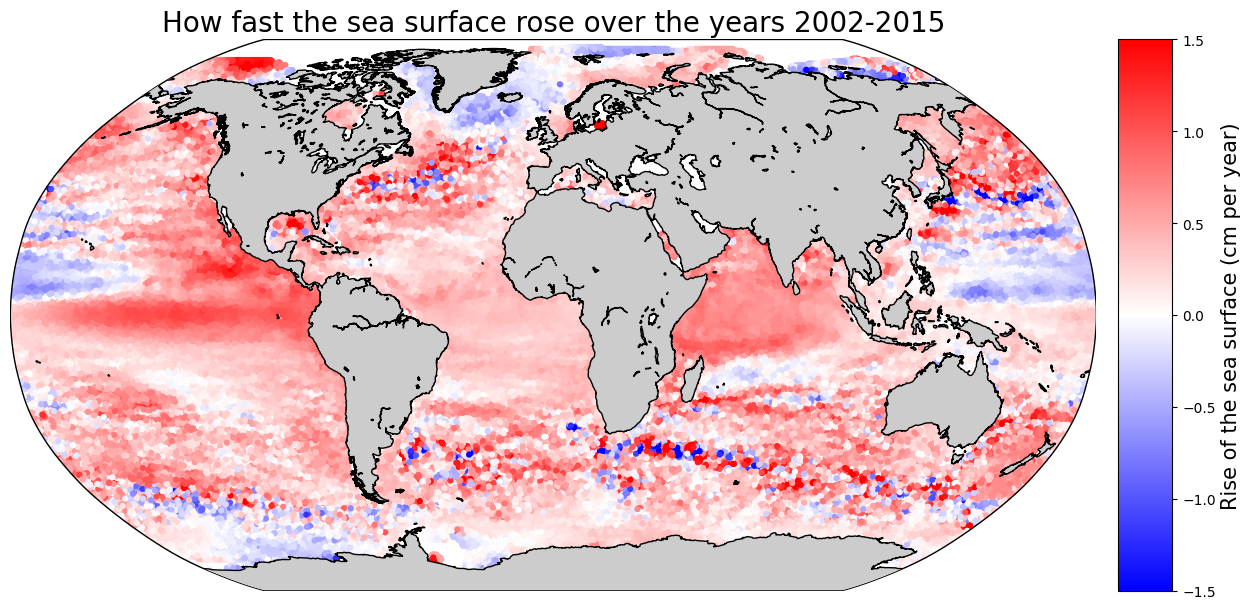

In [ ]:
plot_im(ssh_slope.lon, ssh_slope.lat, ssh_slope.slope * 100, 20, 'Rise of the sea surface (cm per year)')
title('How fast the sea surface rose over the years 2002-2015', size=20)

In [ ]:
# For France
ssh_slope_france = ssh_slope[(ssh_slope['lat'] < 60) & (ssh_slope['lat'] > 35) & ((ssh_slope['lon'] > 350))] #(ssh_slope['lon'] < 15)
plot_im(ssh_slope_france.lon, ssh_slope_france.lat, ssh_slope_france.slope* 90, 20, 'Rise of the sea surface (m)')
title('How fast the sea surface rose over the years 2002-2015', size=20)

# need to plot 2 figures and merge them

Text(0.5, 1.0, 'How fast the sea surface rose over the years 2002-2015')

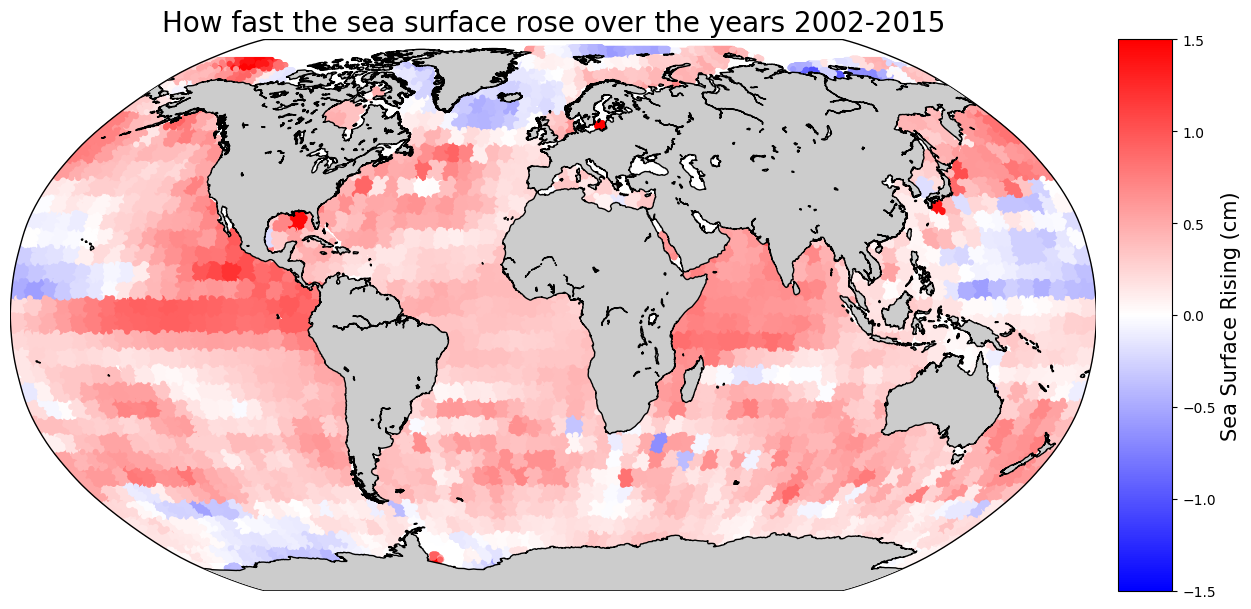

In [ ]:
df = ssh_slope.copy()

dim = 5 # merge pixels into areas of dim x dim

df['lat_zone'] = (df['lat'] // dim).astype(int)
df['lon_zone'] = (df['lon'] // dim).astype(int)

grouped = df.groupby(['lat_zone', 'lon_zone'])

zone_stats = grouped.agg({
    'mean_ssh_first': 'mean',
    'mean_ssh_last': 'mean'
}).reset_index()

delta_t = (735963.0-731002.0)/365
zone_stats['slope'] = (zone_stats['mean_ssh_last'] - zone_stats['mean_ssh_first']) / delta_t

df = pd.merge(
    df,
    zone_stats,
    on=['lat_zone', 'lon_zone'],
    suffixes=('', '_zone')
)

plot_im(df['lon'], df['lat'], df['slope_zone'] * 100, 20, 'Sea Surface Rising (cm)')
title('How fast the sea surface rose over the years 2002-2015', size=20)

In [ ]:
pip install netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 35.3 MB/s eta 0:00:00
